In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Read the Excel file
excel_path = 'data/toxsci-17-0480-File002.xlsx'

# First, let's see what sheets are available
xl_file = pd.ExcelFile(excel_path)
print(f"Available sheets: {xl_file.sheet_names}")
print(f"Number of sheets: {len(xl_file.sheet_names)}")

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [ ]:
# Read the first sheet to understand the structure
df_first = pd.read_excel(excel_path, sheet_name=0, nrows=30)
print("First sheet structure:")
print(f"Shape: {df_first.shape}")
print(f"\nColumn names:")
print(df_first.columns.tolist())
print(f"\nFirst 30 rows:")
print(df_first)

First sheet structure:
Shape: (30, 20)

Column names:
['Compound', 'DSSTox_Substance_Id', 'CAS', 'Reference', 'Species', 'Species.Weight', 'Species.Weight.Units', 'Dose', 'Dose.Units.and.Type', 'Time', 'Time.Units', 'Media', 'Media.Units', 'Value', 'Units', 'Route', 'Source', 'LOQ', 'Subject', 'info']

First 30 rows:
   Compound DSSTox_Substance_Id      CAS Reference Species  Species.Weight  \
0     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
1     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
2     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
3     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
4     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
5     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
6     2,4-D       DTXSID0020442  94-75-7  RTI 2015     rat         0.30503   
7     2,4-D       DTXSID0020442  94-75-7  RTI 2015     ra

In [ ]:
# Read the full dataset
df = pd.read_excel(excel_path, sheet_name=0)
print(f"Full dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique chemicals (DSSTox_Substance_Id): {df['DSSTox_Substance_Id'].nunique()}")
print(f"\nSample of unique chemicals:")
print(df[['Compound', 'DSSTox_Substance_Id']].drop_duplicates().head(10))

Full dataset shape: (2454, 20)

Columns: ['Compound', 'DSSTox_Substance_Id', 'CAS', 'Reference', 'Species', 'Species.Weight', 'Species.Weight.Units', 'Dose', 'Dose.Units.and.Type', 'Time', 'Time.Units', 'Media', 'Media.Units', 'Value', 'Units', 'Route', 'Source', 'LOQ', 'Subject', 'info']

Unique chemicals (DSSTox_Substance_Id): 45

Sample of unique chemicals:
        Compound DSSTox_Substance_Id
0          2,4-D       DTXSID0020442
66      Alachlor       DTXSID1022265
132   Alprazolam       DTXSID4022577
164   Antipyrine       DTXSID6021117
171    Bensulide       DTXSID9032329
321  Bisphenol A       DTXSID7020182
359     Boscalid       DTXSID6034392
435     Bosentan       DTXSID7046627
450     Carbaryl       DTXSID9020247
524  Carbendazim       DTXSID4024729


In [ ]:
# Extract time course data by grouping by DSSTox_Substance_Id, Subject, and Dose
# For each chemical, extract Time and Value columns, handling multiple subjects and doses

# Convert Time and Value to numeric
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# Remove rows with missing Time or Value
df_clean = df.dropna(subset=['Time', 'Value']).copy()

# Replace NA values in Subject column with "Subject_1"
if 'Subject' in df_clean.columns:
    df_clean['Subject'] = df_clean['Subject'].fillna('Subject_1')
    # Also handle string "NA" if present
    df_clean['Subject'] = df_clean['Subject'].replace('NA', 'Subject_1')
    # Handle pandas NA string representation
    df_clean['Subject'] = df_clean['Subject'].replace('nan', 'Subject_1')

# Handle Dose column - convert to string for grouping, keep original for display
if 'Dose' in df_clean.columns:
    df_clean['Dose_str'] = df_clean['Dose'].astype(str)
    df_clean['Dose_original'] = df_clean['Dose']

# Extract route of administration (iv/po) from Dose.Units.and.Type column
if 'Dose.Units.and.Type' in df_clean.columns:
    def extract_route(dose_type_str):
        """Extract route (iv/po) from dose type string like 'mg/kg iv' or 'mg/kg po'"""
        if pd.isna(dose_type_str) or dose_type_str == '':
            return None
        dose_type_str = str(dose_type_str).strip()
        # Split by space and get the last part
        parts = dose_type_str.split()
        if len(parts) > 0:
            last_part = parts[-1].lower()
            # Check if it's iv or po
            if last_part in ['iv', 'po']:
                return last_part
            # Also check for variations like 'iv.', 'po.', etc.
            if last_part.startswith('iv'):
                return 'iv'
            if last_part.startswith('po'):
                return 'po'
        return None
    
    df_clean['Route_Admin'] = df_clean['Dose.Units.and.Type'].apply(extract_route)
    print(f"Extracted route of administration:")
    print(f"  Unique routes: {df_clean['Route_Admin'].value_counts().to_dict()}")

print(f"After cleaning (removing NaN in Time/Value): {len(df_clean)} rows")
print(f"Unique chemicals with valid data: {df_clean['DSSTox_Substance_Id'].nunique()}")
print(f"Unique subjects: {df_clean['Subject'].nunique() if 'Subject' in df_clean.columns else 'N/A'}")
print(f"Unique doses: {df_clean['Dose'].nunique() if 'Dose' in df_clean.columns else 'N/A'}")

# Group by DSSTox_Substance_Id and extract time courses (with subject and dose information)
all_time_courses = {}

for substance_id, group in df_clean.groupby('DSSTox_Substance_Id'):
    # Get compound name (use first occurrence)
    compound_name = group['Compound'].iloc[0] if 'Compound' in group.columns else substance_id
    
    # Check if there are multiple subjects and doses for this chemical
    if 'Subject' in group.columns:
        unique_subjects = group['Subject'].dropna().unique()
        n_subjects = len(unique_subjects)
    else:
        unique_subjects = ['Subject_1']  # Default if no Subject column
        n_subjects = 1
    
    if 'Dose' in group.columns:
        unique_doses = group['Dose'].dropna().unique()
        n_doses = len(unique_doses)
    else:
        unique_doses = [None]
        n_doses = 1
    
    # Store time courses with subject and dose information
    time_course_series = []
    
    # Group by both Subject and Dose
    for subject in unique_subjects:
        subject_group = group[group['Subject'] == subject].copy()
        
        for dose in unique_doses:
            if dose is not None:
                dose_group = subject_group[subject_group['Dose'] == dose].copy()
            else:
                dose_group = subject_group.copy()
            
            if len(dose_group) == 0:
                continue
            
            # Sort by time
            dose_group_sorted = dose_group.sort_values('Time')
            
            # Extract time and concentration values
            time_values = dose_group_sorted['Time'].values
            conc_values = dose_group_sorted['Value'].values
            
            if len(time_values) > 0:
                # Get dose units if available
                dose_units = dose_group['Dose.Units.and.Type'].iloc[0] if 'Dose.Units.and.Type' in dose_group.columns else ''
                
                time_course_series.append({
                    'time': time_values,
                    'concentration': conc_values,
                    'subject': subject,
                    'dose': dose,
                    'dose_units': dose_units,
                    'n_points': len(time_values)
                })
    
    # Create a label with compound name and substance ID
    label = f"{compound_name}\n({substance_id})"
    
    all_time_courses[label] = {
        'substance_id': substance_id,
        'compound': compound_name,
        'time_course_series': time_course_series,
        'n_subjects': n_subjects,
        'n_doses': n_doses,
        'total_points': sum(s['n_points'] for s in time_course_series)
    }

print(f"\nExtracted {len(all_time_courses)} time course series")
print(f"\nSample time courses:")
for i, (label, data) in enumerate(list(all_time_courses.items())[:5]):
    print(f"  {label}: {data['n_subjects']} subject(s), {data['n_doses']} dose(s), {data['total_points']} total data points")

Extracted route of administration:
  Unique routes: {'po': 844, 'iv': 828}
After cleaning (removing NaN in Time/Value): 1672 rows
Unique chemicals with valid data: 45
Unique subjects: 186
Unique doses: 77

Extracted 45 time course series

Sample time courses:
  Cyclosporin A
(DTXSID0020365): 1 subject(s), 2 dose(s), 28 total data points
  2,4-D
(DTXSID0020442): 6 subject(s), 5 dose(s), 38 total data points
  Phenacetin
(DTXSID1021116): 1 subject(s), 1 dose(s), 9 total data points
  Alachlor
(DTXSID1022265): 6 subject(s), 6 dose(s), 41 total data points
  Imipramine
(DTXSID1043881): 1 subject(s), 2 dose(s), 14 total data points


In [ ]:
# Get units information for labeling
units_info = df_clean.groupby('DSSTox_Substance_Id').agg({
    'Units': 'first',
    'Time.Units': 'first',
    'Media': 'first'
}).to_dict('index')

print("Units information sample:")
for i, (sub_id, info) in enumerate(list(units_info.items())[:5]):
    print(f"  {sub_id}: {info}")

Units information sample:
  DTXSID0020365: {'Units': 'mg/kg', 'Time.Units': 'h', 'Media': 'Plasma concentration'}
  DTXSID0020442: {'Units': 'mg/kg', 'Time.Units': 'h', 'Media': 'Plasma concentration'}
  DTXSID1021116: {'Units': 'mg/kg', 'Time.Units': 'h', 'Media': 'Plasma concentration'}
  DTXSID1022265: {'Units': 'mg/kg', 'Time.Units': 'h', 'Media': 'Plasma concentration'}
  DTXSID1043881: {'Units': 'mg/kg', 'Time.Units': 'h', 'Media': 'Plasma concentration'}


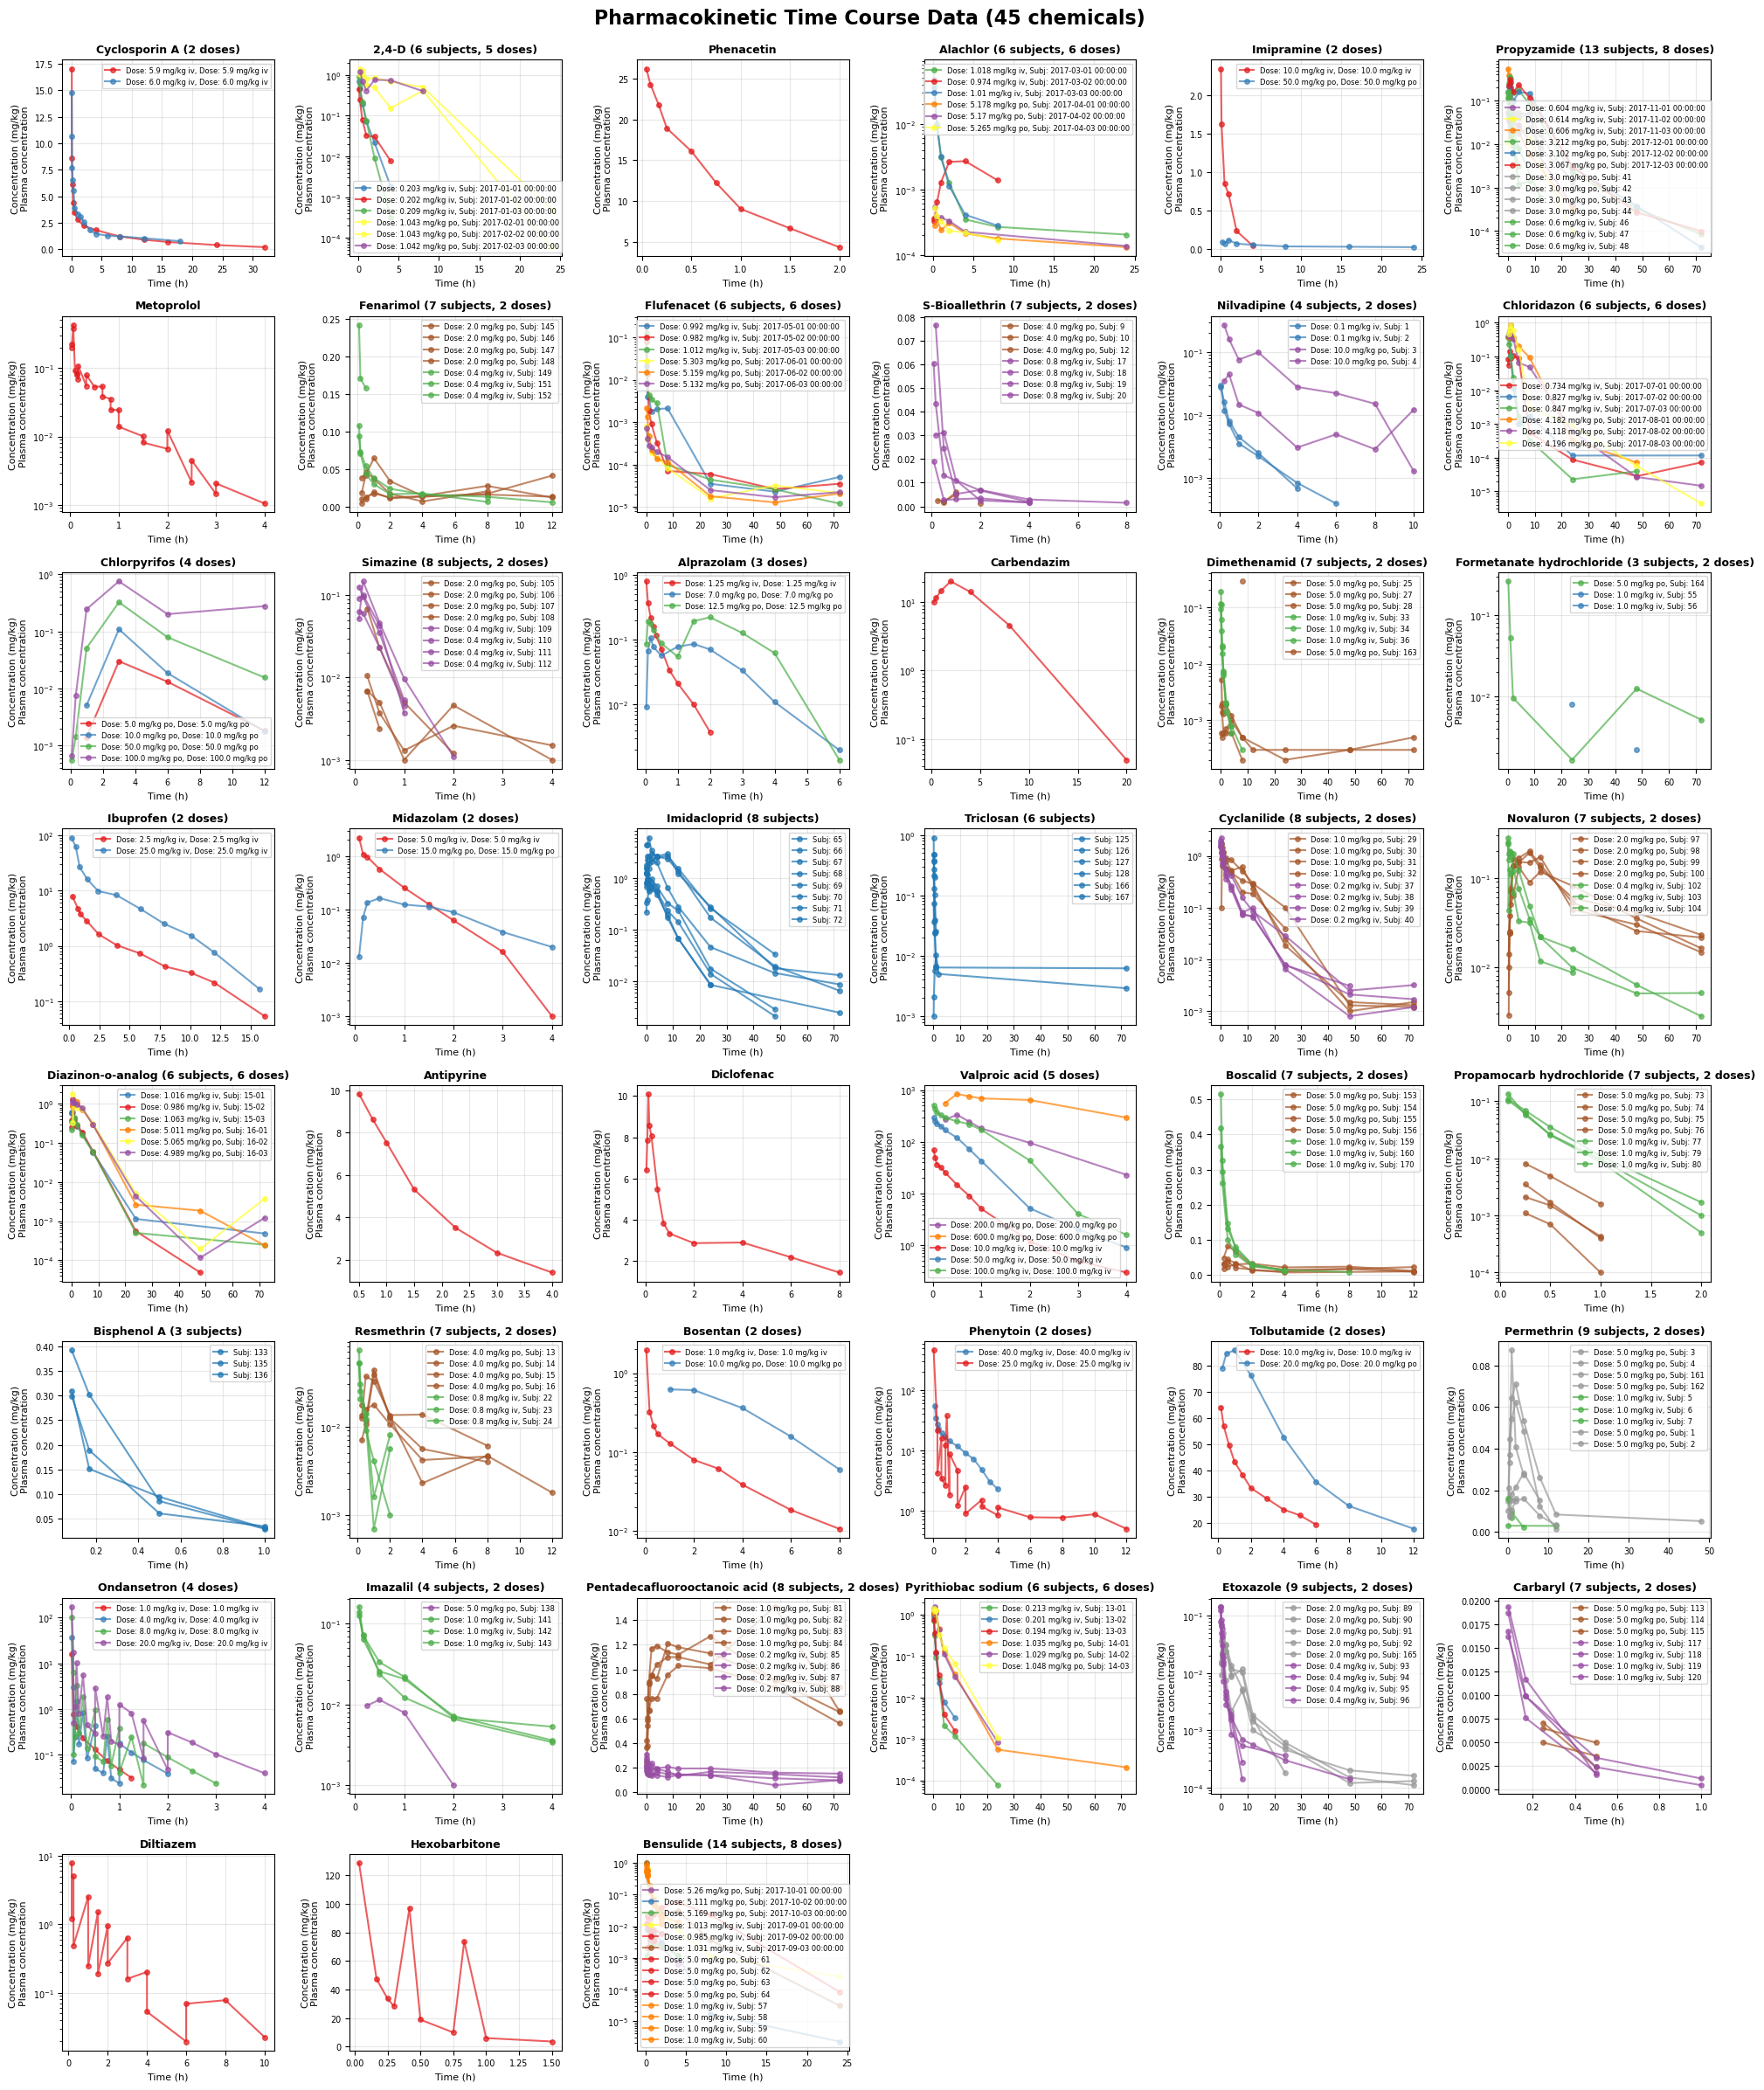

Plotted 45 time course series

Summary statistics:
  Total data points: 1672
  Average points per chemical: 37.2
  Chemicals with multiple subjects: 27
  Chemicals with multiple doses: 35


In [ ]:
# Plot all time courses in separate subplots
# For chemicals with multiple subjects and/or doses, overlay them with different colors/styles
if len(all_time_courses) > 0:
    n_chemicals = len(all_time_courses)
    chemicals = list(all_time_courses.keys())
    
    # Calculate grid dimensions (6 columns)
    n_cols = 6
    n_rows = int(np.ceil(n_chemicals / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
    axes = axes.flatten() if n_chemicals > 1 else [axes]
    
    # Color palette for doses (use different colors for different doses)
    dose_colors = plt.cm.Set1(np.linspace(0, 1, 10))  # Support up to 10 doses
    # Line styles for subjects (if multiple subjects per dose)
    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]
    
    for idx, (chemical_name, data) in enumerate(all_time_courses.items()):
        ax = axes[idx]
        
        substance_id = data['substance_id']
        time_course_series = data['time_course_series']
        n_subjects = data['n_subjects']
        n_doses = data['n_doses']
        
        # Get units for this chemical
        units = units_info.get(substance_id, {})
        time_unit = units.get('Time.Units', 'hr')
        conc_unit = units.get('Units', '')
        media = units.get('Media', '')
        
        # Get unique doses for color mapping
        unique_doses = sorted([s['dose'] for s in time_course_series if s['dose'] is not None])
        if len(unique_doses) == 0:
            unique_doses = [None]
        dose_color_map = {dose: dose_colors[i % len(dose_colors)] for i, dose in enumerate(unique_doses)}
        
        # Plot each time course series
        all_concentrations = []
        legend_handles = []
        legend_labels = []
        
        for series in time_course_series:
            time = series['time']
            conc = series['concentration']
            subject = series['subject']
            dose = series['dose']
            dose_units = series['dose_units']
            
            all_concentrations.extend(conc)
            
            # Determine color based on dose
            if dose is not None:
                color = dose_color_map[dose]
            else:
                color = 'steelblue'
            
            # Determine line style based on subject (if multiple subjects per dose)
            # Group by dose to see if we need different line styles
            if n_subjects > 1 and n_doses > 1:
                # Multiple subjects and doses - use color for dose, style for subject
                subject_idx = int(str(subject).split('_')[-1]) - 1 if 'Subject_' in str(subject) else 0
                linestyle = line_styles[subject_idx % len(line_styles)]
                marker = 'o'
            elif n_subjects > 1:
                # Only multiple subjects - use different colors
                subject_idx = int(str(subject).split('_')[-1]) - 1 if 'Subject_' in str(subject) else 0
                color = plt.cm.tab10(subject_idx / max(n_subjects, 1))
                linestyle = '-'
                marker = 'o'
            else:
                # Single subject or multiple doses only
                linestyle = '-'
                marker = 'o'
            
            # Create label for legend
            label_parts = []
            if n_doses > 1 and dose is not None:
                dose_str = f"{dose}"
                if dose_units:
                    dose_str += f" {dose_units}"
                label_parts.append(f"Dose: {dose_str}")
            if n_subjects > 1:
                label_parts.append(f"Subj: {subject}")
            elif n_doses > 1:
                # If only multiple doses, show dose in label
                if dose is not None:
                    dose_str = f"{dose}"
                    if dose_units:
                        dose_str += f" {dose_units}"
                    label_parts.append(f"Dose: {dose_str}")
            
            label = ", ".join(label_parts) if label_parts else None
            
            # Plot the time course
            line = ax.plot(time, conc, marker=marker, markersize=4, linewidth=1.5, 
                          color=color, linestyle=linestyle, alpha=0.7, label=label)
            
            # Store for legend if needed (avoid duplicates)
            if label and label not in legend_labels:
                legend_handles.append(line[0])
                legend_labels.append(label)
        
        # Set title (use compound name only for cleaner display)
        title = data['compound'] if data['compound'] else substance_id
        title_parts = []
        if n_subjects > 1:
            title_parts.append(f"{n_subjects} subjects")
        if n_doses > 1:
            title_parts.append(f"{n_doses} doses")
        if title_parts:
            title += f' ({", ".join(title_parts)})'
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        # Set labels with units
        ax.set_xlabel(f'Time ({time_unit})', fontsize=8)
        ylabel = f'Concentration'
        if conc_unit:
            ylabel += f' ({conc_unit})'
        if media:
            ylabel += f'\n{media}'
        ax.set_ylabel(ylabel, fontsize=8)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)
        
        # Add legend if multiple subjects or doses
        if n_subjects > 1 or n_doses > 1:
            if legend_handles and legend_labels:
                ax.legend(legend_handles, legend_labels, fontsize=6, loc='best', ncol=1)
        
        # Set y-axis to log scale if concentrations span orders of magnitude
        if len(all_concentrations) > 0:
            all_conc_array = np.array(all_concentrations)
            all_conc_array = all_conc_array[all_conc_array > 0]  # Remove zeros for ratio calculation
            if len(all_conc_array) > 0 and all_conc_array.max() / all_conc_array.min() > 100:
                ax.set_yscale('log')
    
    # Hide unused subplots
    for idx in range(n_chemicals, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Pharmacokinetic Time Course Data ({n_chemicals} chemicals)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted {n_chemicals} time course series")
    print(f"\nSummary statistics:")
    print(f"  Total data points: {sum(d['total_points'] for d in all_time_courses.values())}")
    print(f"  Average points per chemical: {np.mean([d['total_points'] for d in all_time_courses.values()]):.1f}")
    print(f"  Chemicals with multiple subjects: {sum(1 for d in all_time_courses.values() if d['n_subjects'] > 1)}")
    print(f"  Chemicals with multiple doses: {sum(1 for d in all_time_courses.values() if d['n_doses'] > 1)}")
else:
    print("No time course data extracted. Please check the data structure.")

In [ ]:
# Extract and plot time course data for PO (oral) route only
# Filter data to only include Route_Admin == 'po'
df_po = df_clean[df_clean['Route_Admin'] == 'po'].copy()

print(f"PO route data: {len(df_po)} rows")
print(f"Unique chemicals with PO data: {df_po['DSSTox_Substance_Id'].nunique()}")
print(f"Unique subjects: {df_po['Subject'].nunique() if 'Subject' in df_po.columns else 'N/A'}")
print(f"Unique doses: {df_po['Dose'].nunique() if 'Dose' in df_po.columns else 'N/A'}")

# Group by DSSTox_Substance_Id and extract time courses (with subject and dose information)
all_time_courses_po = {}

for substance_id, group in df_po.groupby('DSSTox_Substance_Id'):
    # Get compound name (use first occurrence)
    compound_name = group['Compound'].iloc[0] if 'Compound' in group.columns else substance_id
    
    # Check if there are multiple subjects and doses for this chemical
    if 'Subject' in group.columns:
        unique_subjects = group['Subject'].dropna().unique()
        n_subjects = len(unique_subjects)
    else:
        unique_subjects = ['Subject_1']  # Default if no Subject column
        n_subjects = 1
    
    if 'Dose' in group.columns:
        unique_doses = group['Dose'].dropna().unique()
        n_doses = len(unique_doses)
    else:
        unique_doses = [None]
        n_doses = 1
    
    # Store time courses with subject and dose information
    time_course_series = []
    
    # Group by both Subject and Dose
    for subject in unique_subjects:
        subject_group = group[group['Subject'] == subject].copy()
        
        for dose in unique_doses:
            if dose is not None:
                dose_group = subject_group[subject_group['Dose'] == dose].copy()
            else:
                dose_group = subject_group.copy()
            
            if len(dose_group) == 0:
                continue
            
            # Sort by time
            dose_group_sorted = dose_group.sort_values('Time')
            
            # Extract time and concentration values
            time_values = dose_group_sorted['Time'].values
            conc_values = dose_group_sorted['Value'].values
            
            if len(time_values) > 0:
                # Get dose units if available
                dose_units = dose_group['Dose.Units.and.Type'].iloc[0] if 'Dose.Units.and.Type' in dose_group.columns else ''
                
                time_course_series.append({
                    'time': time_values,
                    'concentration': conc_values,
                    'subject': subject,
                    'dose': dose,
                    'dose_units': dose_units,
                    'n_points': len(time_values)
                })
    
    # Create a label with compound name and substance ID
    label = f"{compound_name}\n({substance_id})"
    
    all_time_courses_po[label] = {
        'substance_id': substance_id,
        'compound': compound_name,
        'time_course_series': time_course_series,
        'n_subjects': n_subjects,
        'n_doses': n_doses,
        'total_points': sum(s['n_points'] for s in time_course_series)
    }

print(f"\nExtracted {len(all_time_courses_po)} time course series for PO route")
print(f"\nSample time courses:")
for i, (label, data) in enumerate(list(all_time_courses_po.items())[:5]):
    print(f"  {label}: {data['n_subjects']} subject(s), {data['n_doses']} dose(s), {data['total_points']} total data points")

PO route data: 844 rows
Unique chemicals with PO data: 38
Unique subjects: 96
Unique doses: 41

Extracted 38 time course series for PO route

Sample time courses:
  2,4-D
(DTXSID0020442): 3 subject(s), 2 dose(s), 20 total data points
  Alachlor
(DTXSID1022265): 3 subject(s), 3 dose(s), 19 total data points
  Imipramine
(DTXSID1043881): 1 subject(s), 1 dose(s), 8 total data points
  Propyzamide
(DTXSID2020420): 7 subject(s), 4 dose(s), 57 total data points
  Metoprolol
(DTXSID2023309): 1 subject(s), 1 dose(s), 27 total data points


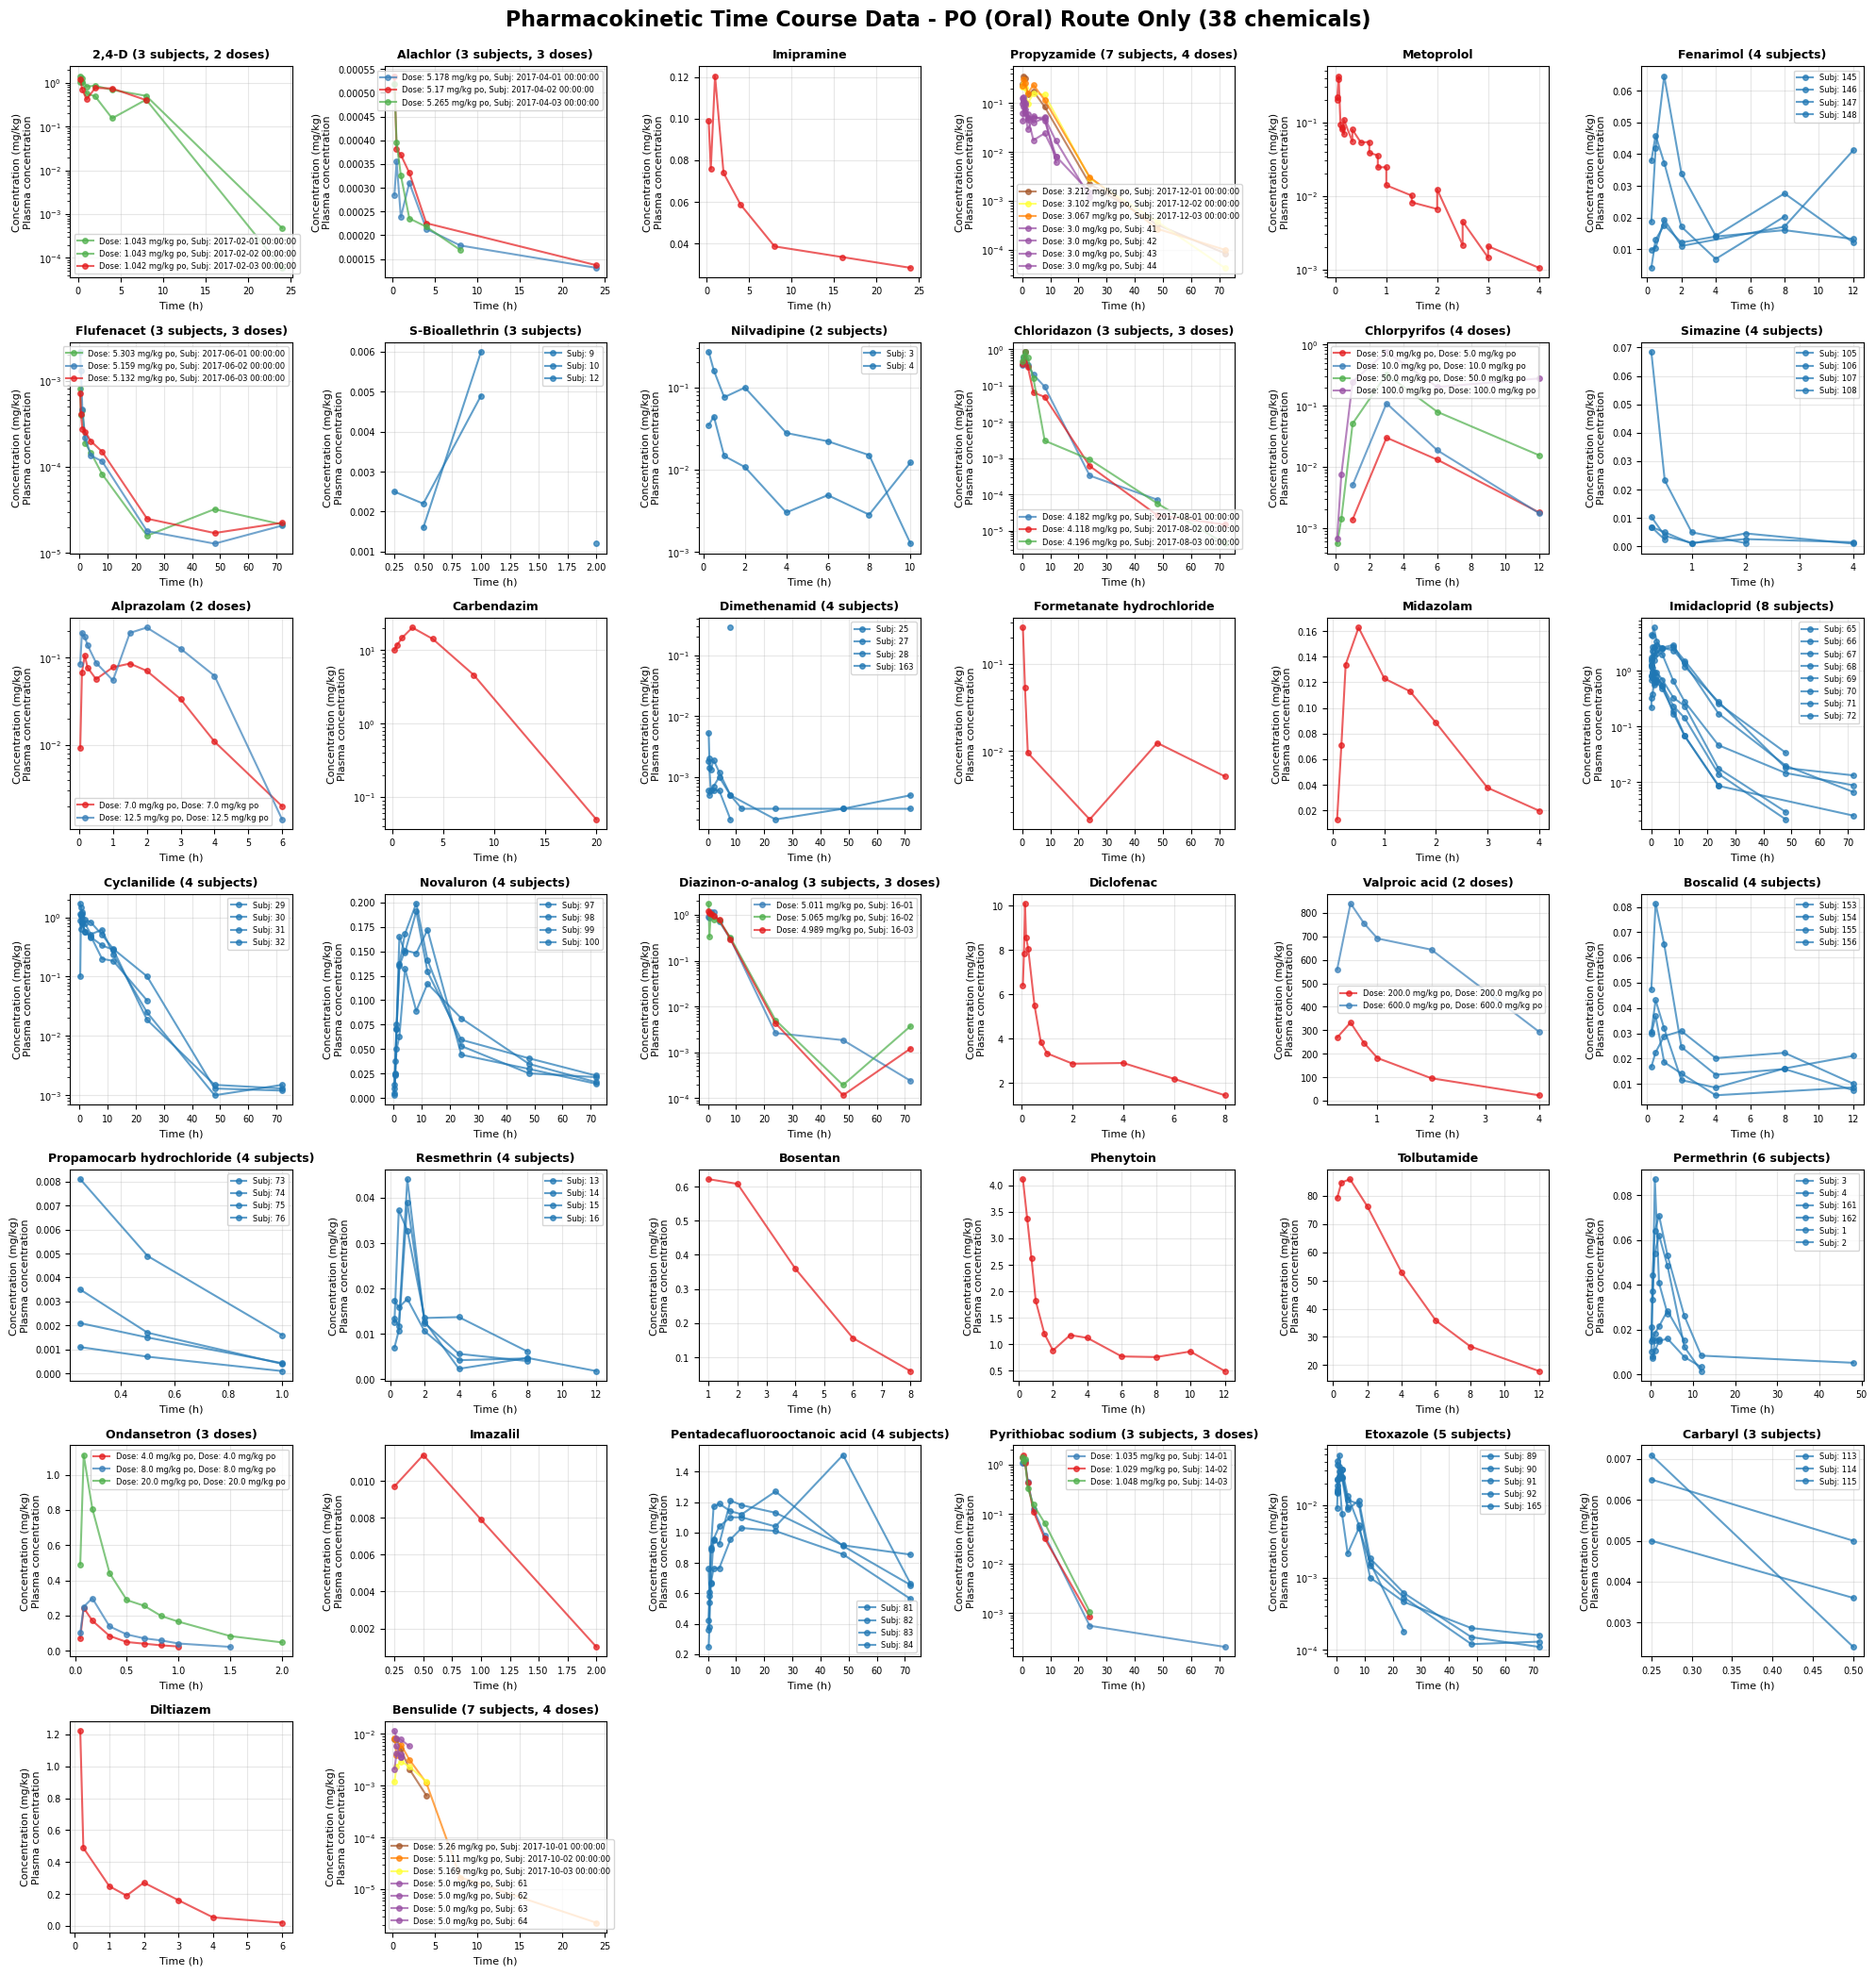

Plotted 38 time course series for PO route

Summary statistics:
  Total data points: 844
  Average points per chemical: 22.2
  Chemicals with multiple subjects: 23
  Chemicals with multiple doses: 12


In [ ]:
# Plot PO route time courses in separate subplots
# For chemicals with multiple subjects and/or doses, overlay them with different colors/styles
if len(all_time_courses_po) > 0:
    n_chemicals = len(all_time_courses_po)
    chemicals = list(all_time_courses_po.keys())
    
    # Calculate grid dimensions (6 columns)
    n_cols = 6
    n_rows = int(np.ceil(n_chemicals / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
    axes = axes.flatten() if n_chemicals > 1 else [axes]
    
    # Color palette for doses (use different colors for different doses)
    dose_colors = plt.cm.Set1(np.linspace(0, 1, 10))  # Support up to 10 doses
    # Line styles for subjects (if multiple subjects per dose)
    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]
    
    for idx, (chemical_name, data) in enumerate(all_time_courses_po.items()):
        ax = axes[idx]
        
        substance_id = data['substance_id']
        time_course_series = data['time_course_series']
        n_subjects = data['n_subjects']
        n_doses = data['n_doses']
        
        # Get units for this chemical
        units = units_info.get(substance_id, {})
        time_unit = units.get('Time.Units', 'hr')
        conc_unit = units.get('Units', '')
        media = units.get('Media', '')
        
        # Get unique doses for color mapping
        unique_doses = sorted([s['dose'] for s in time_course_series if s['dose'] is not None])
        if len(unique_doses) == 0:
            unique_doses = [None]
        dose_color_map = {dose: dose_colors[i % len(dose_colors)] for i, dose in enumerate(unique_doses)}
        
        # Plot each time course series
        all_concentrations = []
        legend_handles = []
        legend_labels = []
        
        for series in time_course_series:
            time = series['time']
            conc = series['concentration']
            subject = series['subject']
            dose = series['dose']
            dose_units = series['dose_units']
            
            all_concentrations.extend(conc)
            
            # Determine color based on dose
            if dose is not None:
                color = dose_color_map[dose]
            else:
                color = 'steelblue'
            
            # Determine line style based on subject (if multiple subjects per dose)
            # Group by dose to see if we need different line styles
            if n_subjects > 1 and n_doses > 1:
                # Multiple subjects and doses - use color for dose, style for subject
                subject_idx = int(str(subject).split('_')[-1]) - 1 if 'Subject_' in str(subject) else 0
                linestyle = line_styles[subject_idx % len(line_styles)]
                marker = 'o'
            elif n_subjects > 1:
                # Only multiple subjects - use different colors
                subject_idx = int(str(subject).split('_')[-1]) - 1 if 'Subject_' in str(subject) else 0
                color = plt.cm.tab10(subject_idx / max(n_subjects, 1))
                linestyle = '-'
                marker = 'o'
            else:
                # Single subject or multiple doses only
                linestyle = '-'
                marker = 'o'
            
            # Create label for legend
            label_parts = []
            if n_doses > 1 and dose is not None:
                dose_str = f"{dose}"
                if dose_units:
                    dose_str += f" {dose_units}"
                label_parts.append(f"Dose: {dose_str}")
            if n_subjects > 1:
                label_parts.append(f"Subj: {subject}")
            elif n_doses > 1:
                # If only multiple doses, show dose in label
                if dose is not None:
                    dose_str = f"{dose}"
                    if dose_units:
                        dose_str += f" {dose_units}"
                    label_parts.append(f"Dose: {dose_str}")
            
            label = ", ".join(label_parts) if label_parts else None
            
            # Plot the time course
            line = ax.plot(time, conc, marker=marker, markersize=4, linewidth=1.5, 
                          color=color, linestyle=linestyle, alpha=0.7, label=label)
            
            # Store for legend if needed (avoid duplicates)
            if label and label not in legend_labels:
                legend_handles.append(line[0])
                legend_labels.append(label)
        
        # Set title (use compound name only for cleaner display)
        title = data['compound'] if data['compound'] else substance_id
        title_parts = []
        if n_subjects > 1:
            title_parts.append(f"{n_subjects} subjects")
        if n_doses > 1:
            title_parts.append(f"{n_doses} doses")
        if title_parts:
            title += f' ({", ".join(title_parts)})'
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        # Set labels with units
        ax.set_xlabel(f'Time ({time_unit})', fontsize=8)
        ylabel = f'Concentration'
        if conc_unit:
            ylabel += f' ({conc_unit})'
        if media:
            ylabel += f'\n{media}'
        ax.set_ylabel(ylabel, fontsize=8)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)
        
        # Add legend if multiple subjects or doses
        if n_subjects > 1 or n_doses > 1:
            if legend_handles and legend_labels:
                ax.legend(legend_handles, legend_labels, fontsize=6, loc='best', ncol=1)
        
        # Set y-axis to log scale if concentrations span orders of magnitude
        if len(all_concentrations) > 0:
            all_conc_array = np.array(all_concentrations)
            all_conc_array = all_conc_array[all_conc_array > 0]  # Remove zeros for ratio calculation
            if len(all_conc_array) > 0 and all_conc_array.max() / all_conc_array.min() > 100:
                ax.set_yscale('log')
    
    # Hide unused subplots
    for idx in range(n_chemicals, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Pharmacokinetic Time Course Data - PO (Oral) Route Only ({n_chemicals} chemicals)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted {n_chemicals} time course series for PO route")
    print(f"\nSummary statistics:")
    print(f"  Total data points: {sum(d['total_points'] for d in all_time_courses_po.values())}")
    print(f"  Average points per chemical: {np.mean([d['total_points'] for d in all_time_courses_po.values()]):.1f}")
    print(f"  Chemicals with multiple subjects: {sum(1 for d in all_time_courses_po.values() if d['n_subjects'] > 1)}")
    print(f"  Chemicals with multiple doses: {sum(1 for d in all_time_courses_po.values() if d['n_doses'] > 1)}")
else:
    print("No PO route time course data found.")